In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw10.ipynb")

In [2]:
%matplotlib inline

# Final Project: Predictive Modelling and Model Comparision

Names: Noah Calabrese and Marc Serebrisky

Student IDs: 525386 and 526170 (respectively)

Collaborators: TBD


## Instructions

This homework is an _open-ended final project_ for our class.

We will focus on Data Profiling and Supervise Machine Learning including Feature Engineering, Feature Selection, and Model Selection & Comparison.

We will be using the techniques and approaches introduced throughout the course focusing on the following topics:

* [M0] Python for DS
* [M1] The DS and ML Workflows
* [M2] Exploratory Data Analsyis
* **[M3] Linear Regression (if applicable - depends on problem/dataset)**
* **[M4] Linear Classification (if applicable - depends on problem/dataset)**
* [M5] Sentiment Analysis (if applicable - depends on problem/dataset)
* [M6] Ethical Thinking for Data Science (if applicable - depends on problem/dataset)
* **[M7] Performance Evaluation: Overfitting & Cross-Validation**
* **[M8] Clustering K-Means (if applicable - depends on problem/dataset)** 
* **[M9] Similarity-based Learning K-NN (if applicable - depends on problem/dataset)**
* **[M10] More Models (Decision Tree, Random Forest, Neural Network) for Feature Engineering & Model Comparision & Selection**
* **[M11] DS Workflow in Python: Data Profiling and ML Pipelines**

The main focus of this project is majorly on the last modules [M7]-[M11]. In particular, it will be helpful to review **Lab 3 & hw 3 onwards for more clarification**.
Most of the things you will do in this final project are explained in `Lab10` and `Lab11`. Then, review the other labs and hws to recap the general workflow of our DS approaches to the various problems we have worked on so far. This will help you to be prepared for all the steps in this project, so that you do not miss anything. 

In general, you should feel free to import any package that we have previously used in class. Ensure that all plots have the necessary components that a plot should have (e.g. axes labels, a title, a legend).

> **!! Do not use any packages/methods/models that we did not discuss in this class !!**

Additionally, note that this assignment is more like a project than a typical homework and it will have a slightly different structure than the hws in the past. One of the reasons why Jupyter Notebooks are so popular in the field is because you can really treat them like notebooks to explain your findings as you discover them. In this assignment, we provide some **Problem** stubs following the DS workflow and you will need to fill in the analysis and structure as you go.

Furthermore, in addition to recording your collaborators on this homework, please also remember to cite/indicate all external sources used when finishing this assignment. This includes peers, TAs, and links to online sources. 

Frequently **save** your notebook!

### Collaborators and Sources
Furthermore, in addition to recording your **collaborators** on this homework, please also remember to **cite/indicate all external sources** used when finishing this assignment. 
> This includes peers, TAs, and links to online sources. 

Note that these citations will not free you from your obligation to submit your _own_ code and write-ups, however, they will be taken into account during the grading and regrading process.

In [3]:
# collaborators and sources:
# Albert Einstein and Marie Curie
# https://developers.google.com/edu/python/strings

# your code here
answer = 'my answer'

### Submission instructions
* Submit this Python notebook, including your answers in the code cells as homework submission.
* **Feel free to add as many cells as you need to** — just make sure you don't change what we gave you. 
* **Does it spark joy?** Note that you will be partially graded on the presentation (_cleanliness, clarity, comments_) of your notebook so make sure you [Marie Kondo](https://lifehacker.com/marie-kondo-is-not-a-verb-1833373654) your notebook before submitting it.

In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "1" # run this first!

## 1. Introduction

For our final project this semester, we'll take a look at data for Melbourne Housing Price Prediction
https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot.


As you have seen throughout the semseter we have learned various techniques to solve a problem task (Classification, Regression, Clustering etc.) starting from problem formulation to EDA to model building to model evaluation and performing feaure engineering and selection in order to improve the model's performance.
You will be combining all the knowledge learned so far in this final project. You will be making assuptions and decisions on your own with appropriate justifications in writeups about how to improve the prediction model using all the tools and techniques learned so far and provide the best model at the end.


The project aims at building a model of housing prices to predict median house values in Melbourne using the provided dataset. This model should learn from the data and be able to predict the median housing price in any district, given all the other metrics.

Our goal will be to use this dataset to gain some insight about characteristics of different features.
We will be using data profiling from pandas and create models (hopefully more than 3) and compare them to find out which model performed the best and probably explain why it is the best model among all in this data.


### Problem 1.1

Download the data and load it in this notebook for further processing and analysis.

In [5]:
# your code here
import pandas as pd
data = pd.read_csv("utility/data/melb_data.csv", dtype = str)
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')
data

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


**Write-up!** Describe the data, answering questions including, but not limited to, these: Where does the data come from? How was it obtained? How many examples and features does the dataset have? What kinds of features are in the dataset? What values can these features take? What kind of data science problem is this? What application area does the dataset fall into? What kind of prediction (regression, classification or clustering) we are doing with this dataset and why?
> **Hint**: Recall, our goal is to build a model of housing prices to predict median house values.

**Your Answer Here:**
The data was publicly scraped from Domain.com.au by an individual named Tony Pino, who based on the Kaggle information "cleaned it well". The data set is from the housing market in Melbourne, Australia, which at the time of cleaning the data had a boom in their housing market. There are 13580 examples presented in the dataset, which you can see at the bottom of the table when it shows the amount of rows in the dataset since examples are rows, and 21 features, represented in the same area as examples but are the columns of the dataset. There are a variety in terms of the type of features in the dataset, there are categorical features such as: Suburb (categorizing where the houses are by the suburban community it belongs to), and region name which simply categorizes by the general region the house is in. There are also numeric features (continuous and discrete) in the dataset. Continuous numeric features are represented by land size and building area which represent the size of the land and building. Discrete numeric features are represented by property count which represents the amount of properties in the region/ suburb and the year built which is the year the building was built.

The application area that the dataset falls into is residential real estate analysis and housing price prediction. That is what Tony Pino collected the data for after all and it is best suited for that venture since it has all the necessary components to analyze and predict housing prices in Melbourne. The type of prediction this falls into is regression since we are doing predictive analysis, with a heavy emphasis on the numeric values given by the houses in Melbourne. And as we have it, price is a numeric continuous variable which is best suited for regression. Classification is best for discrete or categorical variables, which is not exactly what we are attempting to do with this dataset and clustering is not good at predictive analysis since it is hard to extrapolate out of clusters, it's best at exploratory analysis. So, regression is the best suited prediction type to go with for this dataset.

### Problem 1.2: Getting Familiar with the Data

Generate the data report using __ProfileReport__ as we did in lab 11.

In [5]:
#!pip uninstall -y numba visions ydata-profiling
#!pip install numba==0.56.4
#!pip install visions==0.7.5
#!pip install ydata-profiling==4.6.1

In [6]:
from ydata_profiling import ProfileReport

profile = ProfileReport(data, title = "Profile Report of Homes in Melbourne")
profile.to_file("profile_report.html") #to store elsewhere since the size of the file is to large for to commit to git

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Problem 1.3: Data Description

**Write-up!** What are the major highlights and interesting aspects in the report generated in the previous cell (or in your own EDA process). 
Describe your insights using the data/features/visualizations/statistics. Be sure to consider the relationship among features such as correlation and interaction, as well as distributions, missing data, outliers. Include additional visualizations as necessary.

**Major Highlights in the Data:** Through the profile report generated by Ydata, it has unveiled everything we could possibly use to understand and clean our data. Immediately after generating the report, we are presented with an overview of the data declaring that we have 4.6% missing cells, which we will have to clean by removing the rows impairing our dataset in our data preprocessing section later in this project. The report also supplies us with important alerts that it found throughout the data. We are given the variables with the highest correlation, which we can see is Rooms, Bedroom2, and bathrooms, which are all highly correlated with each other (the specific value is also given by the heatmap/ table provided in the report a little later on in the report). Inherently this makes sense to have a correlation of 0.96 (number retrieved from correlation table in the report) with Bedroom2 since Bedroom2 is just a check of the bedrooms using different sources to scrape the data together. Similarly with bathrooms, the more bedrooms a house has, typically there are bathrooms to match the amount of bedrooms, bigger houses have more bedrooms and bathrooms, making the correlation near 0.6. Then, through the alert tab it is clear as to why some of these variables have high correlation with each other. For example, longitude and latitude are highly correlated with postalcode since they are both location based and property count to RegionName and CouncilArea, since those are inherent to the area that they surveyed and got the data from. The property count will be higher in certain regions, giving it the high correlation.

We are also given the 'weakest links' in terms of our data in the alerts tab. What we mean by this is we are told the variables with the most missing data and the most biased data, representing what variables we have to utilize with extra caution. BuildArea has 47.5% missing values, YearBuilt has 39.6%, and CouncilArea has 10.1% missing values; so we have to exercise extra caution around these variables and spend attention to cleaning them. BuildArea and Landsize are both heavily skewed, per the profile, which means the information we get from those data points may be not as convincing as other variables.

The profile report also goes in depth in each variable and what their distribution looks like, giving us the mean, range, outliers, what is missing from each variable, etc. Basically performing every execution we would normally have to do to analyze the data before we process and model it. For example, in the rooms variable, we can see that most of the distribution is centered around 3, with a mean of 2.9. And that it has an outlier within the data, the house that has 10 rooms since there is no data point around it. And for price we can see the mean is $1,075,684.1, which is one of the most important variables in this data set since we are looking at house purchasing and prediction of prices, so to have this as an immediate benchmark is very useful. The distributions given in the profile are insightful since we are able to see possible outliers, if it's skewed (rather than being told by the alerts), and see where most of the data is concentrated. And, honestly, looking at the distribution for Landsize and BuildingArea it will be very difficult to use these variables in analysis and further down the road in EDA process. They have only one large concentrated bar of data, showing very little distribution, heavy skew, and a lot of missing values (supported by the alerts we analyzed earlier). Most of every other data, such as rooms, price, etc. are fairly well distributed, have clear peaks (single or bimodal graphs), and have usable data. Some may have slight skew, but in the scheme of large sample sizes, that makes sense and it is nearly impossible to avoid (this is clear in the distance variable where there is a slight right skew to it). There is one of these individual reports for every variable in the dataset, all producing helpful and insightful data to utilize later, those were just examples to help boast its helpfulness.

There is also an interaction graph provided to help show the correlation between how they often and on what interval they interact in. This is relatively helpful because it's able to further the correlation heatmap and table's findings by representing specifically where in the data they are interacting and correlating with each other. It helps take the data a step further. The profile report has an intergraph for every single variable against every single variable. If you were to set it against rooms and Bedroom2, you'd see points, with shallow to deep blue to represent the interaction, forming a relatively linear line. Helping further the correlation heatmap's findings, as said before

In [7]:
from IPython.display import HTML

external_url = 'https://drive.google.com/drive/u/0/folders/1uM_p5lXVLuqVFW6boixhl-4aJsjwCDkp' 

link_html = f'<a href="{external_url}" target="_blank">Click to view the 55MB report (External Link)</a>'

HTML(link_html)

Use this link to access the file report from Noah Calabrese's drive. It was too large to commit, so this is the best work around available. The zip file and actual profile report are there to access and view.

### Problem 1.4: Split the Data

Extract input (X) and output (y) data from the dataset. 

Use the train and test split from the scikit learn library to split the data into 80% training and 20% testing.

Then, initalize the Kfolds. Be sure to use these folds when executing cross validation below so that the results are comparable.

In [8]:
# your code here
from sklearn.model_selection import train_test_split, KFold

y_col = 'Price'
X_cols = ['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Lattitude', 'Longtitude', 'Propertycount', 'YearBuilt', 'Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']

X = data[X_cols]
y = data[y_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


n_splits= 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)


**Write-up!** Why 80% train and 20% test split is considered a good practice? How would you pick the train-test split size if the dataset is relatively small or large? What is the purpose of using cross validation technique and how does it ensure model robustness? What is Data snooping and how do you avoid it?

**Answer here:** An 80% train and 20% test split is generally considered good practice because 80% allows enough data to train the model in a proper way, where there is just enough to properly fit it but not under/ over fit it. Any more percent, you run the risk of overfitting the model to the training data which makes the test result worse than it could be. And similarly, if you had under 80% training data you run the risk of underfitting your model, not training it enough to properly test the testing data. It's considered the ideal fit since it's the 'goldilocks' percentage, right in the middle of what you want.

If the data was small, then the biggest concern is that you will underfit the data or the variance is going to be high. To help mitigate these concerns, you will most likely want to raise the testing percentage from 80% to 85% or even 90% since that will help ensure the model is well trained and lower the variance. It will help generalize the data better, but now since it's even higher than the normal percentage overfitting is running a risk, but that's what happens when you do not have enough data to go around. If the data was large, then you will want to stick with the 80 20 split, since it's the most optimal split, as we have discussed above, and there is enough data to train and test. It allows for the proper and most optimized testing results.

The purpose of using a cross validation technique is to address certain problems such as overfitting the model. It utilizes techniques to estimate the fit of the model, and in this case specifically at different k folds (K-Fold cross validation). When the data is cut into k folds, you use k-1 to train the model and the remaining 1 to validate the model. Then, after the k iterations of the model we will be able to see the performance scores after each iteration. Then, through each iteration we are able to average a final, robust estimate of the model. Through this technique, it eliminates bias because every fold gets to be utilized as the validation set once, which allows a reliable well trained/ validated estimate. It also resolves some worries about overfitting since it's being validated on each fold, which means it is able to be generalized over the entire training dataset, making it generalize very well. And since it's being validated in every fold, if it is overfit at any point, the validation score will reflect a very low value. All of this and more, ensures a robustness, properly trained model.

Data snooping is when you use your test set data in the training, feature engineering, or in model selection. You influence your model by trying to get it to move closer and fit closer to the testing set, allowing data to be seen by your model early. This also creates a poor estimate when trying to use the model for a different test set, since the data snooping has infested the model and influenced its behaviors. Sometimes this can happen from improper scaling techniques, not adhering to a set training test split, like the 80/20 split we usually do, etc. So, to avoid it, ensure that you are utilizing a correct data split, if you scale fit the scaling function to the training data and then use that function on the test data as well, and simply just be careful when traversing through your data.

## Problem 2: Preprocessing and Baseline Models

### Problem 2.1: Preprocessing for the Baseline Models

Let's start by preprocessing the data so that we can train some baseline models. Note that categorical variables will need to be encoded and missing values should be appropriately delt with using imputation. Also, some models may require scaling. Imputation and scaling should be done in a manner that aovids data snooping.
> **Hint:** The use of Scikit-Learn's Pipelines are highly encouraged!

> **Hint:** Not all columns in the provided dataset can or should be used as features directly. If you see any features that need feature extraction to be useful or that don't make any sense to be used, remove them and **document/justify your choices**. Go back to features left/marked for feature extraction in Pronlem 3. 

**Features we want to keep:**

**Target Variable:** Price

**Numeric Variables:** Rooms, Distance, Bedroom2, Bathroom, Car, Landsize, BuildingArea, YearBuilt, Lattitude, Longtitude, PropertyCount

**Cateogorical Variables:** Suburb, Type, Method, CouncilArea, RegionName 

**-----------------------------------------------------------------------------------------------------------------------------------------**

**Features to remove or extract later on:** Address, SellerG, PostCode, Date

In [9]:
# your code here
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), #using median to impute, setting the unknowns to the median.
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), #setting the impute method to mode, setting the unknowns to the mode of the data.
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_features = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']
categorical_features = ['Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder = 'drop'
)


**Quick Explanation:** We first picked the variables that we thought are the most useful and then separated them into the type of variable they are: numeric or categorical variables. Then we decided that utilizing the median form of imputation for numeric is the best choice to encode the data, since it will use the median for the missing data which is robust to outliers, and will not heavily influence the data. Similarly, we chose to use the mode or "the most frequent" imputation technique for categorical. It is scaled for the same reasons as the numeric data, but it has to be mode since categorical must be treated differently because you either cannot calculate a definite median or the median does not mean something substantial. Then we dropped the "pointless" columns since there was too much cardinality in those columns. Address, Date, Seller, and Postalcode are not important for predicting the price of the houses in Melbourne and have too much cardinality to be considered useful. There is too much variation within the columns’ data.

### Problem 2.2: Perform Linear Regression

Perform Linear Regression on training data. Predict the output for the test dataset using the fitted model. Print the root mean squared error (RMSE) and R^2 value from Linear Regression for test data set.


In [10]:
# your code here
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

full_pipeline.fit(X_train, y_train)

y_pred = full_pipeline.predict(X_test)

rmse_2LR = np.sqrt(mean_squared_error(y_test, y_pred))
r2_2LR = r2_score(y_test, y_pred)

print(f'The root mean squared error is {rmse_2LR}') 
print(f'The r squared value is {r2_2LR}') 

The root mean squared error is 354857.7171323286
The r squared value is 0.6829818544231597


**Write-up!** What does R^2 tell us about the model's performance? What does RMSE tell us about the model's performance?

**Answer here:** The R^2 tells us that the variance in the dependent variable (every feature that is not price or removed) is explained by the independent variable (price) in the regression model. Specifically for this scenario, there is a pretty strong, positive relationship between price and the other variables in the csv discussing Melbourne's housing market. The R^2 does not show us everything about the model's performance, but it does give us a good indication if the model is well trained and geared towards the data. And this R^2 value is actually really solid in terms of our model's performance. Meaning that our model, based on the R^2 value, has performed well. The closer to 1 (or -1, though that means there is an inverse relationship between the dependent variables and the independent variable price), the better the model is, and 0.68, in terms of R^2, is very decent.

The RMSE tells a relatively different story for the analysis of the model's performance. The RMSE, also known as the Root Mean Squared Error, represents the average difference between a statistical model's predicted values to the actual, genuine, real values. And the average difference between the model and the actual models for housing prices in Melbourne is, an average of, $354,857.72. Which, quite honestly, is higher than I would have thought. A high RMSE like this represents that there may be more impactful mistakes in the model and not as accurate forecasts provided by the model as there should be.

That's why it is important to calculate and analyze both the R^2 value and the RMSE value since they both give insights into how accurate and well-trained your model is. And in this case, linear regression will most likely not be the most accurate in terms of price prediction.

### Problem 2.3 : Perform K-Nearest Neighbors Regression

Perform K-Nearest Neighbors Algorithm for Regression using cross validation to tune any hyperparameters, such as `n_neighbors`.

Then, using the optimal hyperparameters, train a K-Nearest Neighbors Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from K-Nearest Neighbors Regression on the test datset.

In [11]:
# your code here
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('regressor', KNeighborsRegressor())
])

# Define Hyperparameter Grid
param_grid = {
    'regressor__n_neighbors': [5, 10, 15, 20] 
}

# Perform GridSearchCV (5-Fold Cross-Validation on the training data)
grid_search = GridSearchCV(
    knn_pipeline,  
    param_grid,  
    cv=5,  
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_n_neighbors = grid_search.best_params_['regressor__n_neighbors']
best_model = grid_search.best_estimator_ # The best model fitted on X_train

y_pred_knn = best_model.predict(X_test)

rmse_2knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_2knn = r2_score(y_test, y_pred_knn)

print(f'The root mean squared error is {rmse_2knn}') 
print(f'The r squared value is {r2_2knn}')
print(f'The best numbers of neighbors is {best_n_neighbors}')

The root mean squared error is 324992.5828269387
The r squared value is 0.7340974444480892
The best numbers of neighbors is 20


By the Way: I had to go up to where I loaded the data in and make the price a numeric variable instead of a float since I kept getting hit with an error mentioning "unsupported operand type(s) for /: 'str' and 'int", so I had to coerce all the price data into numeric to fix this. But you cannot see the code in this block, rather I put it directly above where I read the data into the notebook.

**Write-up!** How K-NN is different than Linear regression model and what additional steps you have to take for KNN Regression?

**Answer here:** The K-NN is different than the linear regression model in terms that we got the ability to cross validate, through different grids ensuring that every training set gets to be used to validate the data once. We used a 5-fold cross validation since that is what we have utilized in 1.4 Split the Data, where we chose 5 n-splits, so we chose to keep consistency with that. K-NN regression predicts the price of houses in Melbourne by averaging the target values of the model in the future space. Basically finding the most direct route to those points from the model, through a Euclidean distance typically. The additional steps taken in K-NN regression usually center around the validation technique where you go through each fold of the training set, validating the data as you go. Which is clear in the grid search used above. Linear regression just uses a best fit model through the pipeline calculated to predict the price, whereas the K-NN estimates based off comparing each training data and then utilizing the most efficient path, through the distance calculation.

This is clear since there is a higher R^2 value, 0.734 and a lower RMSE, $324,992.58. The higher R^2 shows that there is an even stronger connection between the dependent variables and the prices of the houses in Melbourne than originally thought in the linear regression model, and the predicted price varies slightly less than in the linear regression which means it is on average more accurate. Though they are both holding high RMSE values, this could mean that the data needs extended cleaning through feature extraction or the data has too many variables or outliers within the variables of the dataset.

We can also see that the best amount of neighbors, given by the K-NN prediction, is 20. This makes for a better and easier prediction since we have more neighbors to compare and base the data off of, aiding in the accuracy of the model. It's less prone to noise this way, making the data more resilient.

### Problem 2.4 : Perform Decision Tree Regression 

Perform Decision Tree Regression using cross validation to tune any hyperparameters, such as `max_depth`.

Then, using the optimal hyperparameters, train a Decision Tree Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Decision Tree Regression on the test dataset.

In [12]:
# your code here
from sklearn.tree import DecisionTreeRegressor

# Define the parameter grid to tune max_depth and min_samples_split
param_grid = {
    'regressor__max_depth': [3, 5, 7, 10, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}


full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Grid search with 5-fold CV
grid_search = GridSearchCV(full_pipeline, param_grid,
                           cv=5,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred_DT = best_model.predict(X_test)

rmse_2DT = np.sqrt(mean_squared_error(y_test, y_pred_DT))
r2_2DT = r2_score(y_test, y_pred_DT)

print(f'The root mean squared error is {rmse_2DT}') 
print(f'The r squared value is {r2_2DT}')

Best hyperparameters: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10}
The root mean squared error is 335001.77583247214
The r squared value is 0.7174665770928097


**Write-up!** What are the advantages or disadvantages of using Decision Tree over Linear Regression and KNN?

**Answer here:** The Decision Tree has decent advantages over Linear Regression and KNN. Typically, what you'll find from a decision tree is the usefulness of how easy it is to interpret and explain. This is because the leaves and tree itself are pretty self-explanatory assuming it's not too large and has too many moving parts, which is similar to this example since it has a max depth of 10 which is very reasonable. It also responds with fairly accurate predictions when suggesting the price for Melbourne houses, very similar to the prices predicted in KNN. With barely a less R squared value and a slightly higher RMSE, which means in this specific case the KNN might be a better predictor. But, if you also valued readability and interpretability then the Decision Tree might be worth a consideration since the results are very close. It also performs cross-validation making it a more reliable set compared to linear regression, similar to how I explained in the example about K-NN right above this. Another pro is that the run time of a decision tree is a lot quicker than KNN but a linear regression time is a lot quicker than both. So, that could factor in if we had an even larger dataset.

Some disadvantages, are obviously that it performs slightly worse than the K-NN model, but also it is known to 'overfit' the model to the data in the training phase. But, hopefully the cross validation is able to help mitigate that. And if there is a lot of variation or noise in the dataset, the model responds harshly to it, having a hard time fitting it into the leaves or having to adjust the entire size of the decision tree, which adds to its space complexity, while compared to KNN and linear regression. Linear Regression is also a super quick analysis comparatively, but it is just significantly less accurate for large datasets such as the one we are working with.

An R^2 value of 0.717 and an RMSE of $335,001.78 is a very good estimation based off the other models we have already analyzed so far. It's better than the linear regression model in every aspect, and slightly worse than K-NN giving a good middle ground of what a predictive model could look like. One that is fairly accurate based on the R^2 value might I add, since 0.72 is a strong positive correlation, one that is worth mentioning since it's close to 1.

Overall, a decision tree is not a bad predictor for the price of houses in Melbourne, but it seems to be just a slight bit worse than K-NN in terms of its actual results.

### Problem 2.5 : Perform Random Forest Regression

Perform Random Forest Regression using cross validation to tune any hyperparameters, such as `n_estimators`.

Then, using the optimal hyperparameters, train a Random Forest Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Random Forest Regression on the test dataset.

In [13]:
# your code here
from sklearn.ensemble import RandomForestRegressor
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10],
}

# Use ONLY 3 folds (cuts compute time by 40%)
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Create pipeline (uses your preprocessor)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=1))
])

grid_search_RF = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=1,
)

# Fit
grid_search_RF.fit(X_train, y_train)

print("Best hyperparameters:", grid_search_RF.best_params_)

best_RF_model = grid_search_RF.best_estimator_
y_pred_RF = best_RF_model.predict(X_test)

rmse_2RF = np.sqrt(mean_squared_error(y_test, y_pred_RF))
r2_2RF = r2_score(y_test, y_pred_RF)

print(f'The root mean squared error is {rmse_2RF}') 
print(f'The r squared value is {r2_2RF}')

Best hyperparameters: {'regressor__max_depth': None, 'regressor__n_estimators': 200}
The root mean squared error is 267557.66279390245
The r squared value is 0.8197769232119471


**Write-up!** Why does a Random Forest ensure better results than a single Decision Tree? 

**Your Answer Here:** To preface everything, I have to say that running this Random Forest Regression Analysis took 173 seconds to execute on the successful attempt and caused my computer to crash 4 times prior to this. Forcing me to make certain edits like making n_jobs = 1 rather than -1 and reducing the amount of folds that I use. This is because with RF Regression, it can make hundreds of trees, creating millions of nodes which is simply too much for my computer to handle. So, I had to reduce it while also balancing the best qualities of the RF regression to ensure that I would get good, quality products.

And good quality products I did receive, as you can see from the root mean squared error, it is reduced all the way down to $267,557.66 which is the lowest RMSE we've seen out of all 4 models and the highest R^2 value sitting at 0.8198. This means that it is the most accurate, and best predictor for the data, out of the models we have tested. The RMSE is low meaning that the actual values are close to the predicted ones, and the R^2 is high which means there is heavy, strong, positive correlation between price and the other variables in terms of the model.

The Random Forest ensures better results than a single decision tree because of a few reasons. As we mentioned earlier, decision trees tend to overfit, making the test data less accurate and less desirable than the Random Forest model. This is due to the sensitivity to noise, such as outliers, and it tends to have a very high variance, creating an overfitting norm. Random Forests are able to reduce overfitting and actually are better built for data that have a lot of noise in it. This is because they are able to create distinct splits that ensure randomness but also proper separation to subset the features. Which means they are able to analyze noisy data, such as the one we have in Melbourne (it's quite a large dataset), and generalize the data much better resulting in better, more accurate testing results.


## 3. Feature Extraction and Selection

### Problem 3.1: Feature Extraction

Apply **feature extraction** in this section in order to derive at least 2 new features. Be sure to apply the same feature extraction to both the training and testing datasets.

**Do this!** In the cells below, **explain** and perform the steps for feature extraction. Make sure that your implementations and write-ups are presented well and effectively describe your workflow. You may add comments or markdown cells for your documentation as you see fit!  

*Grading Note: Your work will be graded for _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report.*

> **Hint**: You can use our previous labs as examples of how you might do this. Remember, you may add as many cells (for code and text) as you need below. Here — we gave you one for free!

In [14]:
for data in [X_train, X_test]:
    for col in ['Rooms', 'Bedroom2', 'Bathroom']:
        data[col] = pd.to_numeric(data[col], errors='coerce')
#print(X_train[['Rooms', 'Bedroom2', 'Bathroom']].dtypes)

**Code Explanation:** Had to ensure that the variables Rooms, Bedroom2, and Bathroom were numeric since they were being considered as objects, so when I tried adding them, it would concatenate them into a long series of numbers (an example being 33.1.01 I believe). So, to ensure that it adds properly I had to add those lines in and print to make sure it was proper and correct.

In [15]:
# your code here
for data in [X_train, X_test]: #necessary to cycle through each column and retreive the values to add later on
    data['TotalRooms'] = data['Rooms'] + data['Bedroom2'] + data['Bathroom'] #adding all the possible room options into one variable
    data.drop(['Rooms', 'Bedroom2', 'Bathroom'], axis=1, inplace=True) #dropping the now useless columns since we have 'TotalRooms' to replace


In [16]:
X_train['YearBuilt'] = pd.to_numeric(X_train['YearBuilt'], errors='coerce')
year_median = X_train['YearBuilt'].median()

for data in [X_train, X_test]:

    data['YearBuilt'] = pd.to_numeric(data['YearBuilt'], errors='coerce')
    data['YearBuilt'].fillna(year_median, inplace=True) #ensuring that the median is filled in where there are NaN's. 
    
    data['PropertyAge'] = 2023 - data['YearBuilt'] #we used 2023 since that is when the dataset was created, for consistency reasons.
    data.drop(['YearBuilt'], axis=1, inplace=True)

In [17]:
data

,Distance,Postcode,Car,Landsize,BuildingArea,Lattitude,Longtitude,Propertycount,Suburb,Type,Method,CouncilArea,Regionname,TotalRooms,PropertyAge
1061,11.2,3186.0,3.0,588.0,NaN,-37.9287,144.99200000000005,10579.0,Brighton,h,S,Bayside,Southern Metropolitan,8.0,53.0
6482,1.9,3003.0,1.0,0.0,83.0,-37.8091,144.952,2230.0,West Melbourne,u,S,Melbourne,Northern Metropolitan,5.0,21.0
8395,6.1,3182.0,0.0,0.0,115.0,-37.8718,144.9767,13240.0,St Kilda,u,SP,Port Phillip,Southern Metropolitan,7.0,93.0
4659,9.9,3044.0,1.0,146.0,106.0,-37.7152,144.9346,7485.0,Pascoe Vale,t,VB,Moreland,Northern Metropolitan,8.0,17.0
7386,9.1,3015.0,2.0,462.0,NaN,-37.8331,144.8715,984.0,South Kingsville,h,SP,Hobsons Bay,Western Metropolitan,5.0,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10455,21.5,3195.0,2.0,545.0,145.0,-37.99827,145.07497,5087.0,Parkdale,h,SP,Kingston,South-Eastern Metropolitan,7.0,73.0
3616,5.6,3101.0,3.0,1334.0,365.0,-37.8029,145.0267,10331.0,Kew,h,S,Boroondara,Southern Metropolitan,18.0,133.0
577,9.7,3103.0,2.0,981.0,260.0,-37.8058,145.0627,5682.0,Balwyn,h,S,Boroondara,Southern Metropolitan,11.0,63.0
12620,14.7,3152.0,3.0,754.0,NaN,-37.88153,145.23003,7082.0,Wantirna South,h,S,NaN,Eastern Metropolitan,15.0,53.0


**Write up!** Explain the feature extraction methods have you implemented and why.

**Your Answer Here:** We were able to extract two new features by combining existing numeric features.

For the first variable, we removed Rooms, Bedroom2, and Bathrooms, instead adding them all into one new variable, being TotalRooms. We decided to take this approach because it seems like the difference between the distinction of the rooms does not make that much of a direct difference, instead what matters is the quantity of total rooms. When we factor all of this together, it makes more sense from a coding perspective, from a memory perspective, and from a logical perspective to combine all of these variables together into one, as this will be a more effective variable to use later on down the line. We also dropped the original three variables that were combined so as to ensure that we do not cause redundant use. This way we keep the necessary and important information that factor into price prediction, but we are also able to remove three variables in exchange for one, which will also improve the runtime of our models and simplify our prediction.

For PropertyAge, we subtracted the age in which the house or property was built, namely YearBuilt, from the date of publication of the dataset, being 2023. By doing this, we are able to keep it standardized, and in a way that is far more digestible for a regression function. By doing this, we are able to further ensure better results, as well as having easier numbers for visualization and machine digestion. It's simply a more usable and informative way to read and understand the data since we will immediately be able to understand the variable and see how it impacts our prediction. It just helps simplify our human needs more, rather than just focusing on the runtime and simplification of the model program.

### Problem 3.2: Feature Selection

Using the original and extracted features as input, perform **feature selection** in this section (statistical, model-based, or iterative feature selection). Be sure to apply the same feature selection to both the training and testing datasets. Note that categorical variables will need to be encoded and missing values should be appropriately delt with using imputation.

**Do this!** In the cells below, **explain** and perform the steps necessary for feature selection. Make sure that your implementations and write-ups are presented well and effectively describe your workflow. You may add comments or markdown cells for your documentation as you see fit!  

*Grading Note: Your work will be graded for _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report.*

> **Hint**: You can use our previous labs as examples of how you might do this. Remember, you may add as many cells (for code and text) as you need below. Here — we gave you one for free!

In [18]:
from sklearn.feature_selection import SelectFromModel

# --- 1. Redefine Preprocessing Pipeline for New Features (Post-FE) ---

# Define the final set of feature names after Problem 3.1
numerical_features_after_fe = ['Distance', 'Car', 'Landsize', 'BuildingArea', 
                               'Lattitude', 'Longtitude', 'Propertycount', 'TotalRooms', 'PropertyAge']
categorical_features_for_pipeline = ['Postcode', 'Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']

numerical_pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_final, numerical_features_after_fe),
        ('cat', categorical_pipeline_final, categorical_features_for_pipeline)
    ],
    remainder='drop'
)

# Using random forest for ranking feature importance, and use optimal parameters from Problem 2.5
rf_selector_estimator = RandomForestRegressor(n_estimators=200, max_depth=None, 
                                              random_state=42, n_jobs=1)

selection_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('selector', SelectFromModel(rf_selector_estimator, threshold='median')) #the processor leads directly into selecting the features
])

selection_pipeline.fit(X_train, y_train) #going through the pipeline in order to retreieve the features

# Transform both training and testing data using the fitted selector
X_train_selected = selection_pipeline.transform(X_train)
X_test_selected = selection_pipeline.transform(X_test)

# Use the optimal n_neighbors=20 found in Problem 2.3. We use KNN to select features for validation.
knn_model = KNeighborsRegressor(n_neighbors=20) 

knn_model.fit(X_train_selected, y_train)

# Predict and evaluate on the transformed and selected test data
y_pred_selected = knn_model.predict(X_test_selected)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected))
r2_selected = r2_score(y_test, y_pred_selected)

print(f"Number of features selected: {X_test_selected.shape[1]}")
print(f"RMSE with selected features (KNN, n=20): {rmse_selected}")
print(f"R^2 Score with selected features (KNN, n=20): {r2_selected}")

Number of features selected: 278
RMSE with selected features (KNN, n=20): 332973.3688295547
R^2 Score with selected features (KNN, n=20): 0.7208776501140357


**Write up** Explain which feature selection method have you selected and why.

**Your Answer Here:** I used a model-based approach with a random forest regressor. This is because Random Forests assign importance to the variables based off prediction error, which I then chose based off whether they were more or less important than the median level of importance assigned to variables. Through the random forest modeling, whilst using the same parameters we used before such as columns used, testing proportion (0.8), and actual RF parameters, just with our newly extracted variables, we are able to select the most important features. We only have to study 278 features now, which speeds up our processing time greatly as well. Random Forest is also able to handle NaN values internally, which I found to be more helpful and simple compared to the other alternative methods we learned in class. Through this we sped up the runtime significantly compared to the other regression tree, but our accuracy through RMSE and R^2 has reduced a considerable amount. This could be since we are utilizing fewer features so the model will be slightly less accurate, but also it could be from the feature extraction since we altered the data to help. Afterwards, I used KNN on the selected features to accurately find the RMSE and R^2 in order to compare a rise/fall in accuracy, which should've risen after feature engineering.

## Problem 4: Preprocessing and Feature Engineered Models

### Problem 4.1: Preprocessing for the Feature Engineered Models

Now that we've removed/added features during feature engineering, we need to update the preprocessing from Problem 2.1. 

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


numerical_features = [
    'TotalRooms',      
    'PropertyAge',     
    'Distance',
    'Car',
    'Landsize',
    'BuildingArea',
    'Lattitude',
    'Longtitude',      
    'Propertycount'
]

categorical_features = ['Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)


### Problem 4.2: Perform Linear Regression

Perform Linear Regression on **engineered training data**. Predict the output for the test dataset using the fitted model. Print the root mean squared error (RMSE) and R^2 value from Linear Regression for test data set.


In [20]:
#COPY PASTED PIPELINE INTO ALL SO I DONT HAVE TO SCROLL :) 
#just a disclaimer i hate redundant code as much as the next guy but i need all the help i can get 

numerical_features = [
    'TotalRooms',      
    'PropertyAge',     
    'Distance',
    'Car',
    'Landsize',
    'BuildingArea',
    'Lattitude',
    'Longtitude',
    'Propertycount'
]

categorical_features = ['Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']


for data in [X_train, X_test]:
    for col in numerical_features:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')


numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)


linreg_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])


linreg_model.fit(X_train, y_train)


y_pred = linreg_model.predict(X_test)


rmse_4LR = np.sqrt(mean_squared_error(y_test, y_pred))
r2_4LR = r2_score(y_test, y_pred)

print("Linear Regression on Engineered Features")
print(f"RMSE: {rmse_4LR}")
print(f"R^2:  {r2_4LR}")

Linear Regression on Engineered Features
RMSE: 355810.8535548887
R^2:  0.6812765662208873


### Problem 4.3 : Perform K-Nearest Neighbors Regression

Perform K-Nearest Neighbors Algorithm for Regression using cross validation to tune any hyperparameters, such as `n_neighbors`. Be sure to use the **data with feature engineering applied**.

Then, using the optimal hyperparameters, train a K-Nearest Neighbors Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from K-Nearest Neighbors Regression on the test datset.

In [21]:
# your code here
#COPY PASTED PIPELINE INTO ALL SO I DONT HAVE TO SCROLL :) 
#just a disclaimer i hate redundant code as much as the next guy but i need all the help i can get 

numerical_features = [
    'TotalRooms',
    'PropertyAge',
    'Distance',
    'Car',
    'Landsize',
    'BuildingArea',
    'Lattitude',
    'Longtitude',
    'Propertycount'
]

categorical_features = ['Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']

for data in [X_train, X_test]:
    for col in numerical_features:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)

knn_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', KNeighborsRegressor())
])

param_grid = {
    'model__n_neighbors': [3, 5, 10, 15, 20, 25, 30],
    'model__weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best hyperparameters from CV:")
print(grid_search.best_params_)


best_knn_model = grid_search.best_estimator_


y_pred_knn = best_knn_model.predict(X_test)


rmse_4knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_4knn = r2_score(y_test, y_pred_knn)

print("Final KNN Regression Results:")
print(f"RMSE: {rmse_4knn}")
print(f"R²:   {r2_4knn}")

Best hyperparameters from CV:
{'model__n_neighbors': 15, 'model__weights': 'distance'}
Final KNN Regression Results:
RMSE: 322292.64769644727
R²:   0.7384971604084452


### Problem 4.4 : Perform Decision Tree Regression 

Perform Decision Tree Regression using cross validation to tune any hyperparameters, such as `max_depth`. Be sure to use the **data with feature engineering applied.**

Then, using the optimal hyperparameters, train a Decision Tree Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Decision Tree Regression on the test dataset.

In [22]:
# your code here
#COPY PASTED PIPELINE INTO ALL SO I DONT HAVE TO SCROLL :) 
#just a disclaimer i hate redundant code as much as the next guy but i need all the help i can get 

numerical_features = [
    'TotalRooms',
    'PropertyAge',
    'Distance',
    'Car',
    'Landsize',
    'BuildingArea',
    'Lattitude',
    'Longtitude',
    'Propertycount'
]

categorical_features = ['Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']


for data in [X_train, X_test]:
    for col in numerical_features:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')


numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)


dt_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])


param_grid = {
    'model__max_depth': [3, 5, 10, 15, 20, None],
    'model__min_samples_leaf': [1, 2, 5, 10],
    'model__min_samples_split': [2, 5, 10]
}


dt_cv = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

dt_cv.fit(X_train, y_train)

print("Best hyperparameters found by CV:")
print(dt_cv.best_params_)


best_dt_model = dt_cv.best_estimator_


y_pred_dt = best_dt_model.predict(X_test)


rmse_4dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_4dt = r2_score(y_test, y_pred_dt)

print("Final Decision Tree Regression Results")
print(f"RMSE: {rmse_4dt}")
print(f"R²:   {r2_4dt}")


Best hyperparameters found by CV:
{'model__max_depth': 20, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Final Decision Tree Regression Results
RMSE: 317129.69480131817
R²:   0.7468083192483213


### Problem 4.5 : Perform Random Forest Regression

Perform Random Forest Regression using cross validation to tune any hyperparameters, such as `n_estimators`. Be sure to use the **data with feature engineering applied.**

Then, using the optimal hyperparameters, train a Random Forest Regressor on the entirety of the training data and predict output for the test dataset using the fitted model.

Print root mean squared error (RMSE) and R^2 from Random Forest Regression on the test dataset.

In [33]:
# your code here
#COPY PASTED PIPELINE INTO ALL SO I DONT HAVE TO SCROLL :) 
#just a disclaimer i hate redundant code as much as the next guy but i need all the help i can get conceptually

numerical_features = [
    'TotalRooms',
    'PropertyAge',
    'Distance',
    'Car',
    'Landsize',
    'BuildingArea',
    'Lattitude',
    'Longtitude',
    'Propertycount'
]

categorical_features = ['Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']


for data in [X_train, X_test]:
    for col in numerical_features:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')


numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)


rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])


param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5]
}


rf_cv = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1
)

rf_cv.fit(X_train, y_train)

print("Best hyperparameters from CV:")
print(rf_cv.best_params_)


best_rf_model = rf_cv.best_estimator_


y_pred_rf = best_rf_model.predict(X_test)


rmse_4rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_4rf = r2_score(y_test, y_pred_rf)

print("Final Random Forest Regression Results")
print(f"RMSE: {rmse_4rf}")
print(f"R²:   {r2_4rf}")


Best hyperparameters from CV:
{'model__max_depth': 30, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Final Random Forest Regression Results
RMSE: 263600.65892336424
R²:   0.8250682681977117


**Overall Conclusion of Part 4:** In this section (all of part 4), we used the base code used in 2.1, but with our adjusted and extracted variables that we generated above. This was to help reduce the columns utilized in the models to help with runtime and accuracy. We were able to reduce the runtime and the accuracy of the random forest regression actually improved. The R^2 value was roughly the same, 0.8198 before feature extraction and 0.8251 after extraction. Meaning more of the variance in the data was able to be explained by the model, inherently meaning the accuracy was improving. And to help justify that claim further, the RMSE also got reduced from 267,557.66 dollars in the original random forest regression to 263,600.66 dollars, which is about 4,000 dollars better. Since we have less of an RMSE in our new model, we can confirm that our model improved, especially with feature selection to help find the most optimal amount of n_estimators to use in the new regression. All of these helped improve the accuracy of the model, which means we can predict the prices of houses in Melbourne with better accuracy than before. Overall, a win-win.

And, to quickly discuss the other regression techniques we used, such as linear regression, K-NN, and Decision Tree Regression, they remained relatively the same as before, with slightly better results. Which means the feature extraction and selection worked very well, even though they still aren't as good as RF regression (that just means the dataset is better suited for RF, not that the other regression models aren't in general worse). It's just a testament to the feature extraction and selection that we did, demonstrating that it helped the overall accuracy of the models


## 5. Model Comparision

### Problem 5.1:

Create some visualizations that compare all the models results using either $R^{2}$ or RMSE. Be sure to include the following visualizations:
1. Performance comparison across the 4 baseline models from problem 2.
2. Performance comparison across the 4 feature engineered models from problem 4.
3. Performance comparison of the baseline models and the feature engineered models.

Feel free to include additional visualizations!

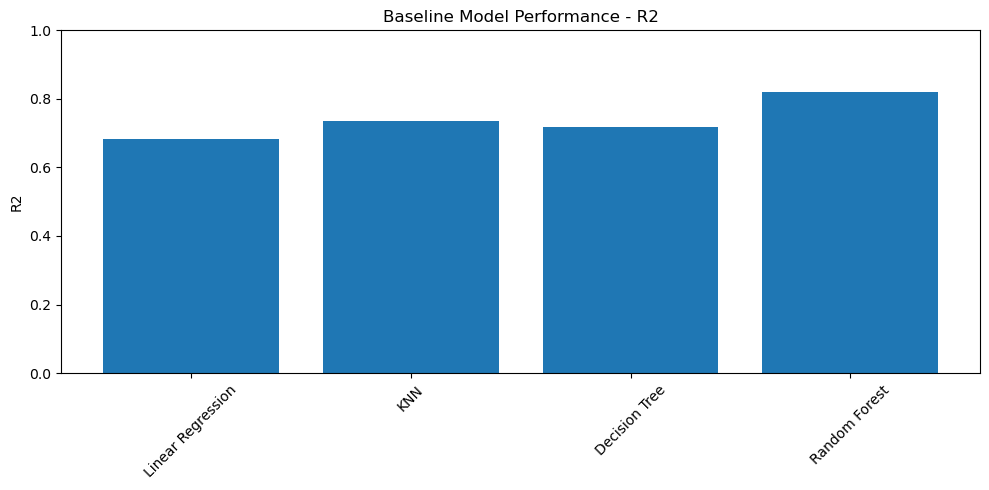

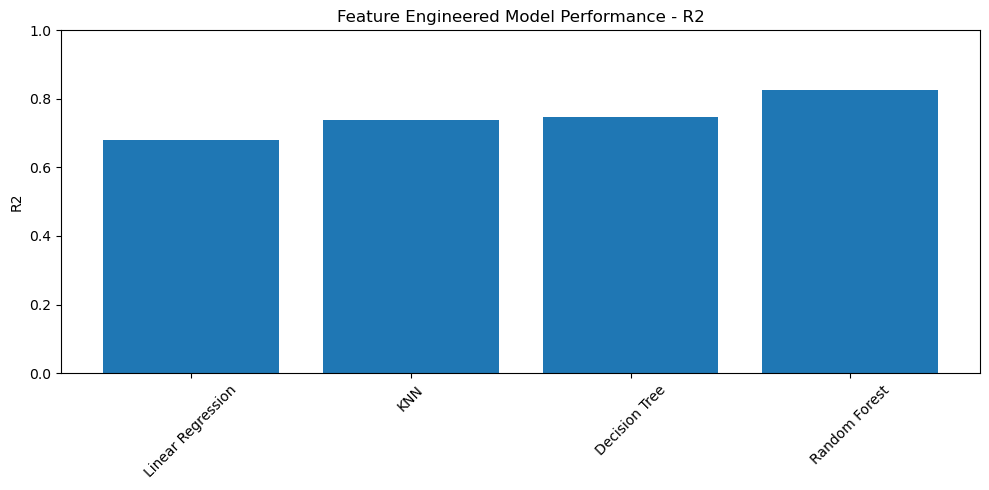

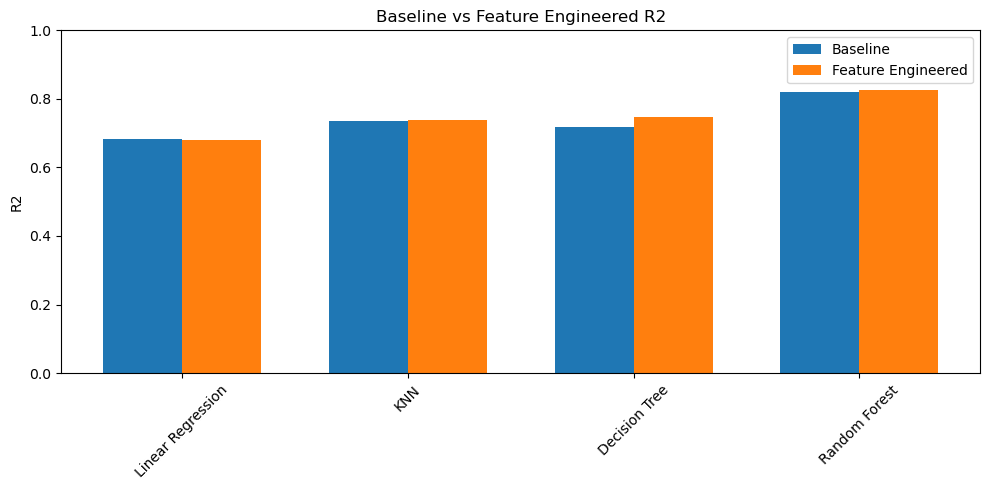

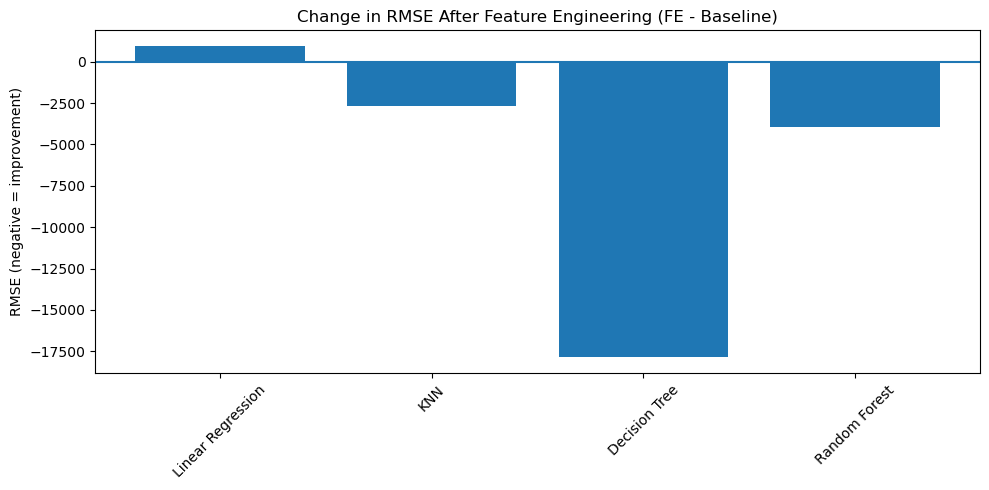

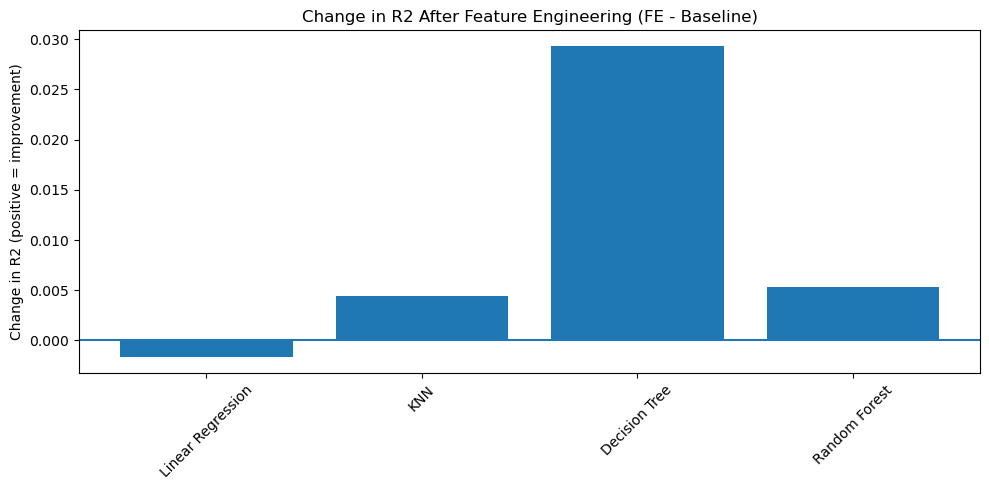

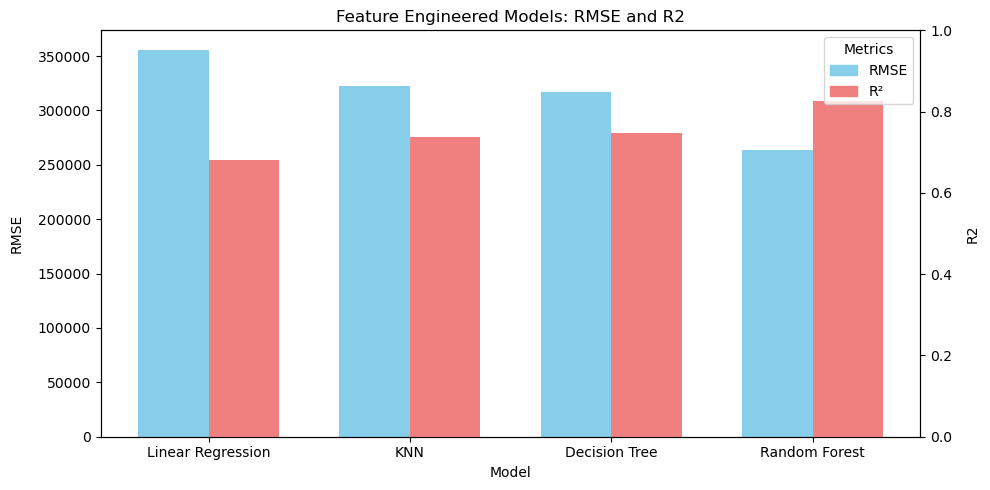

In [32]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest']

baseline_rmse = [rmse_2LR, rmse_2knn, rmse_2DT, rmse_2RF]
fe_rmse       = [rmse_4LR, rmse_4knn, rmse_4dt, rmse_4rf]

baseline_r2 = [r2_2LR, r2_2knn, r2_2DT, r2_2RF]
fe_r2       = [r2_4LR, r2_4knn, r2_4dt, r2_4rf]

x = np.arange(len(models))
width = 0.35


# normal R2

plt.figure(figsize=(10,5))
plt.bar(models, baseline_r2)
plt.title("Baseline Model Performance - R2")
plt.ylabel("R2")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# engineered R2

plt.figure(figsize=(10,5))
plt.bar(models, fe_r2)
plt.title("Feature Engineered Model Performance - R2")
plt.ylabel("R2")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# comparing R2

plt.figure(figsize=(10,5))
plt.bar(x - width/2, baseline_r2, width, label='Baseline')
plt.bar(x + width/2, fe_r2, width, label='Feature Engineered')
plt.title("Baseline vs Feature Engineered R2")
plt.ylabel("R2")
plt.ylim(0, 1)
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# change in RMSE 
# negative = better here

delta_rmse = [fe - base for fe, base in zip(fe_rmse, baseline_rmse)]

plt.figure(figsize=(10,5))
plt.bar(models, delta_rmse)
plt.axhline(0)
plt.title("Change in RMSE After Feature Engineering (FE - Baseline)")
plt.ylabel("RMSE (negative = improvement)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# change in R2
# positive = better

delta_r2 = [fe - base for fe, base in zip(fe_r2, baseline_r2)]

plt.figure(figsize=(10,5))
plt.bar(models, delta_r2)
plt.axhline(0)
plt.title("Change in R2 After Feature Engineering (FE - Baseline)")
plt.ylabel("Change in R2 (positive = improvement)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# rmse vs R2 engineered models

fig, ax1 = plt.subplots(figsize=(10,5))

rmse_bars = ax1.bar(
    x - width/2, 
    fe_rmse, 
    width, 
    color='skyblue', 
    label='RMSE'
)

ax1.set_xlabel("Model")
ax1.set_ylabel("RMSE", labelpad=10)
ax1.tick_params(axis='y')


ax2 = ax1.twinx()
r2_bars = ax2.bar(
    x + width/2, 
    fe_r2, 
    width, 
    color='lightcoral', 
    label='R2'
)

ax2.set_ylabel("R2", labelpad=10)
ax2.set_ylim(0, 1)
ax2.tick_params(axis='y')

plt.xticks(x, models, rotation=45)
plt.title("Feature Engineered Models: RMSE and R2")

legend_elements = [
    plt.Rectangle((0,0), 1, 1, color='skyblue', label='RMSE'),
    plt.Rectangle((0,0), 1, 1, color='lightcoral', label='R²')
]

plt.legend(handles=legend_elements, loc='upper right', title="Metrics")


fig.tight_layout()
plt.show()

**Explanations of the Graphs:** Through the graphs we are able to truly and accurately compare the models that we utilized throughout this project. Rather than just seeing the number difference printed out throughout the project, we can see the visual differences within each given model.

In this first graph, "Baseline Model Performance- R2", we can see a clear and distinct difference in R^2 values immediately, without any feature engineering, when it comes to the Random Forest model. We noticed this throughout the lab, but here we can see that RF regression had the highest R^2 accuracy with K-NN and Decision Tree behind by a noticeable margin (linear regression is significantly smaller). This means that RF model is able to explain the variance within the dataset through the model with the most accuracy, meaning the model is most well suited for the data. It is an important distinction to make since variance is a very volatile part of predictive modeling. Without feature engineering, this means that it was initially the best suited for the data.

In the second graph, "Feature Engineered Model Performance - R2", we see the exact same results as the first graph just with higher R^2 values. This means that after reducing the amount of columns, and enhancing our dataset to the strengths of our models, we were able to see overall higher accuracy throughout each regression technique, but also that Random Forest Regression remains the most accurate in terms of variance. This furthers that the RF model technique is the best choice for predicting the Melbourne housing prices dataset.

In the third graph, "Baseline vs Feature Engineered R2", you are able to see the difference side-by-side. There isn't much of a change but KNN, Decision Tree, and RF all improve, marginally. Linear regression actually slightly reduced (by an insignificant amount), which further proves that we should and will not select linear regression to model/ predict this dataset. The Decision Tree actually had the largest change in R^2, it just is not enough to compare with the RF model, which is clearly and visibly better (has a higher R2 value).

In the fourth graph, "Change in RMSE After Feature Engineering (FE- Baseline)", we can see a useful barplot representing how RMSE was affected by our feature engineering. And overall, they all got reduced by a large amount, except linear regression which furthers that we should NOT select that model to predict house prices in Melbourne. It poorly reacts to feature engineering in both R2 and RMSE values whereas the rest of our models react very positively. This is because linear regression is not too useful when there are various confounding variables and moving parts as the other regression predicting techniques are. In terms of change in RMSE, the Decision Tree again has the best improvement amongst the models, reducing overall RMSE by about 17,500 dollars; whereas RF and KNN reduced RMSE by around 2,500 dollars. This further proves that our feature engineering was received positively, by the majority of models, since the error was reduced. When RMSE goes down, that means the overall accuracy of the model is improving, so the feature engineering has direct impact on improving our model’s accuracy of predicting the data.

In the fifth graph, "Change in R2 After Feature Engineering (FE- Baseline)", we are able to see a lot of what we saw in the third graph just in an enhanced way. R^2 improved on every model (about 0.005 for KNN and RF and 0.275 for DT), except linear regression which dropped R^2 accuracy by about 0.002. This graph helps us see the visualization of the actual number difference occurred by the feature engineering. Which further enhances our first three graphs, putting a number to the change.

In the sixth graph, "Feature Engineered Models: RMSE and R2", we get to see the final product. After all this aforementioned coding, analysis, and breakdown, we finally get to see everything together. The holistic change in the models. And just as we have spoken about before, the Random Forest Regression has the highest R2 value and the lowest RMSE which is the best of both worlds. The lowest price error within the model and the best accuracy in terms of explained variation in the model. There is a noticeable difference in both values compared to the other models, and such a stark difference means that there is no contention about which model to utilize for predicting housing prices in Melbourne. Random Forest is the most accurate by far, with KNN and Decision Tree about tied for second in terms of accuracy of the model, and linear regression was never in contest considering it has the worst RMSE and R^2 due to its overly simplistic modeling technique. It's a simple regression, and it shows, it cannot properly analyze the testing data as well as the other models, it is simply not suited for the variation and several moving parts that are going on in the dataset.

Thus, we are able to come to a proper conclusion considering the code outcomes, the runtime, the baseline outcomes, the feature engineering outcomes, and finally the visualized results. Random Forest Regression is the best suited model for this dataset’s predictive qualities and linear regression is the worst. 5.2 will explain the conclusion in further detail.

### Problem 5.2:

**Write up** Summarize your results and provide some crucial insights about the entire with and without feature engineering process such as which model performed the best and why, based on what metrics and indicators, etc. Which model benefited the most/the least from the feature engineering (if any)?

**Answer here:** The best performing model, both before and after feature engineering, was the Random Forest model. This is likely because, due to many reasons both listed and not listed, housing prices and other features are not directly correlated with one another, and they are very unstable for many reasons. As has been covered many times over, Random Forests do especially well when using variables that are nonlinear, and for something such as housing, which is inherently very variable without a seeming correlation, due to the randomness, Random Forest models will deal with them especially well. This is seen with the R2 values both before and after feature engineering being almost a full 10% more effective and correlated compared to that of the other three models we ran. This ended up having the highest R2 and the lowest RMSE, meaning that it would predict and model the relationships, both off real data and hypothetical, the best out of the four models. I would also expect this to perform the best, because it was by far the most taxing time-wise, as well as heating up my computer to the point I had to set it down off my lap due to discomfort. When we ran the feature engineering, the model that is most improved, as seen in the fifth and sixth graphs, was decisively the decision tree. Because of the way that we ran our variables and engineered the two new ones, we were able to remove a lot of noise and variation from the PropertyAge variable, as well as making fewer points for the decision tree to need to split between when using the TotalRooms variable. This was evidenced with a .03 increase in R2, and a -17500 decrease in the RMSE, by far the most significant change. This change made the decision tree jump to the second most effective of the four models we designed. The least effective, as well as the only model we designed that was hindered by feature engineering, was the Linear Regression, which makes a lot of sense, given the fact that when removing variables, which we did when we replaced many with one when engineering, Linear Regression has less of a correlation. Additionally, since the plethora of variables we used in order to draw a correlation were not particularly linear, the Linear Regression model had a tough time finding any association at all, with a far lower R2 and far higher RMSE compared to its counterparts. And as we have explained thoroughly throughout the project and whilst analyzing the graphs, linear regression is one of the more simple prediction/ regression modeling techniques. Which means that it cannot adhere to our, oftentimes, complex, nonlinear data, making it have worse accuracy and a higher error rate than the other graphs. Not that it was absolute

That's it! Follow the submission instructions below:
* Restart your kernel and run all the cells
* Save your notebook
* Upload the .ipynb notebook directly to Gradescope

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [34]:
grader.check_all()

KeyError: 'otter'

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export()